In [7]:
import pandas as pd

df = pd.read_csv(r'C:\Users\hp\Desktop\Employee Attrition Model\Raw Dataset.csv')

#If someone worked in many companies but stayed less → high leave frequency
# If someone stayed long in one company → low leave frequency
df["LeaveFrequency"] = (
    df["NumCompaniesWorked"] / (df["YearsAtCompany"] + 1)
)

df["LeaveFrequency"] = df["LeaveFrequency"] / df["LeaveFrequency"].max()

#Job satisfaction reflects overall happiness
#Relationship satisfaction reflects interaction with manager/team
#Environment satisfaction reflects workplace support
# Combined → strong proxy for manager feedback

df["ManagerFeedback"] = (
    df["JobSatisfaction"] +
    df["RelationshipSatisfaction"] +
    df["EnvironmentSatisfaction"]
) / 3

df["ManagerFeedback"] = df["ManagerFeedback"] / df["ManagerFeedback"].max()

df["OverTime"] = df["OverTime"].map({"Yes": 1, "No": 0})
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})
df["Over18"] = df["Over18"].map({"Yes": 1, "No": 0})




df = df.drop([
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
], axis=1)


df.to_csv(r'Cleaned_Dataset.csv', index=False)

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,LeaveFrequency,ManagerFeedback
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,0,8,0,1,6,4,0,5,0.142857,0.583333
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,1,10,3,3,10,7,1,7,0.011364,0.750000
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,0,7,3,3,0,0,0,0,0.750000,0.750000
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,0,8,3,3,8,7,3,0,0.013889,0.833333
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,1,6,3,3,2,2,2,2,0.375000,0.583333


In [8]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'LeaveFrequency',
       'ManagerFeedback'],
      dtype='object')

In [9]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print(cat_cols)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus'],
      dtype='object')


In [5]:
df2 = pd.read_csv(r'C:\Users\hp\Desktop\Employee Attrition Model\Cleaned_Dataset.csv')
df2.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'LeaveFrequency',
       'ManagerFeedback'],
      dtype='object')

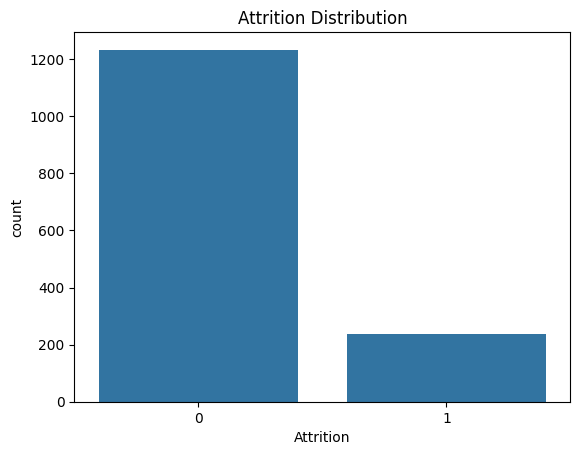

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Attrition", data=df)
plt.title("Attrition Distribution")
plt.show()

# it means few employees left the company, which can lead to class imbalance issues in modeling.

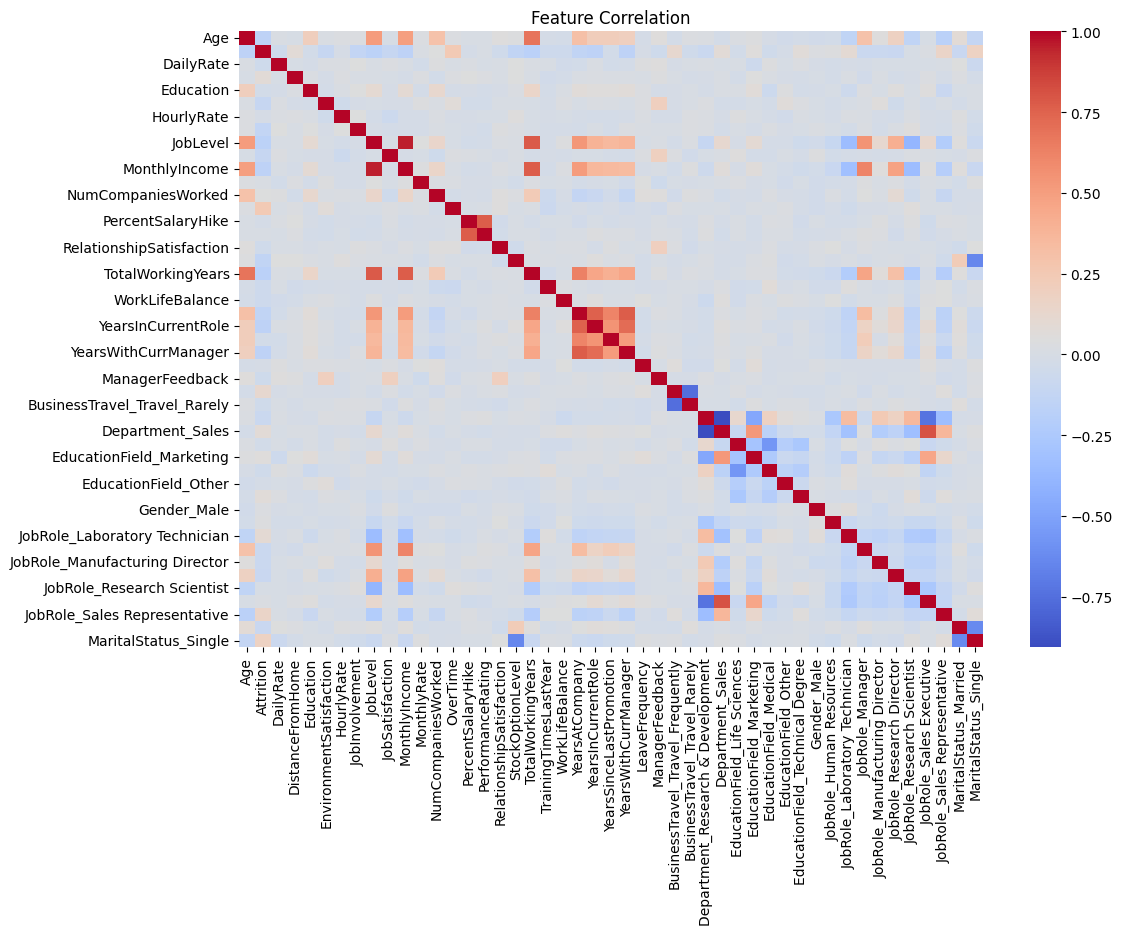

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

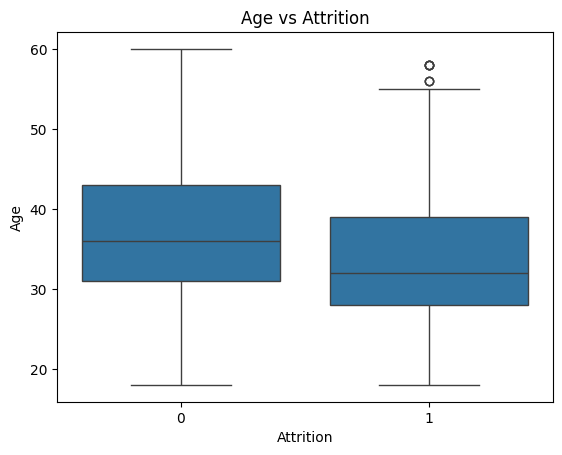

In [ ]:
sns.boxplot(x="Attrition", y="Age", data=df)
plt.title("Age vs Attrition")
plt.show()

# younger employees are more likely to leave, possibly due to career exploration or dissatisfaction.

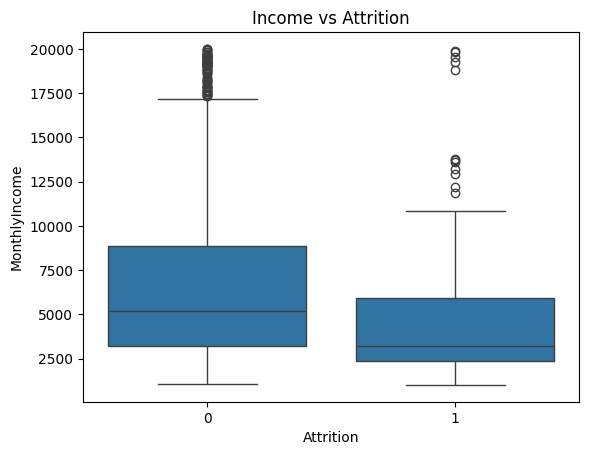

In [ ]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Income vs Attrition")
plt.show()
# lower income employees are more likely to leave, indicating financial dissatisfaction may be a key factor.

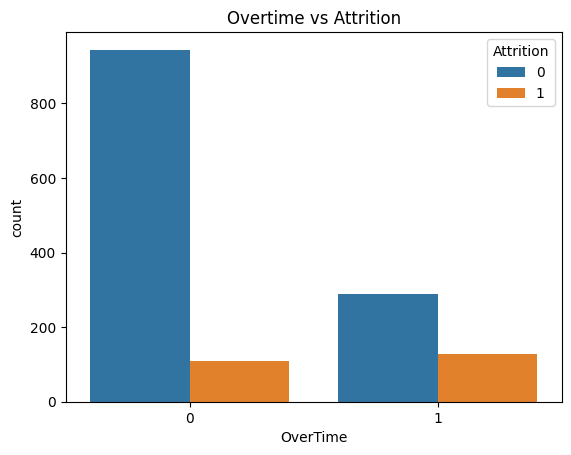

In [9]:
sns.countplot(x="OverTime", hue="Attrition", data=df)
plt.title("Overtime vs Attrition")
plt.show()

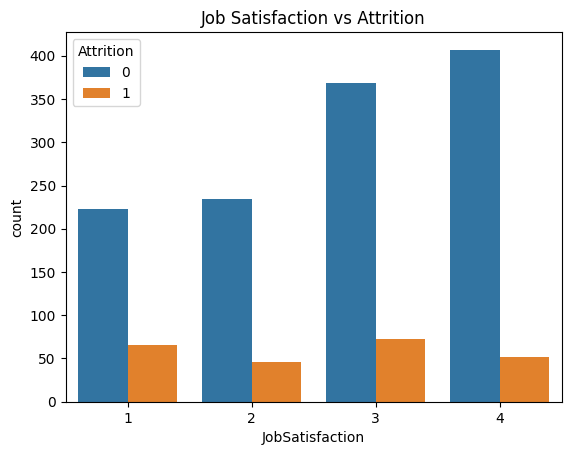

In [10]:
sns.countplot(x="JobSatisfaction", hue="Attrition", data=df)
plt.title("Job Satisfaction vs Attrition")
plt.show()